# Comparing Random Forest and XGBoost modeling performance

## Import required libraries

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [2]:
root_path = Path(".").absolute()
data_path = root_path / "data"
data_path.mkdir(exist_ok=True)

%matplotlib inline

In [3]:
file = data_path / "California_housing.csv"
df = pd.read_csv(file)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X = df.drop(columns=["Target"])
y = df["Target"]

In [5]:
split_data: list[pd.DataFrame | pd.Series] = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = split_data

## Exercise 1

<p>How many observations and features does the dataset have?</p>

In [6]:
N_observations, N_features = X.shape

In [7]:
f"Number of Observations: {str(N_observations)}"

'Number of Observations: 20640'

In [8]:
f"Number of Features: {str(N_features)}"

'Number of Features: 8'

<p>This is a moderately sized dataset used for this analysis. Keep in mind you are only using one dataset so you have to consider that the comparison may change with scale.</p>

## Initialize models

<p>In this step you define the number of base estimators, or individual trees, to be used in each model, and then initialize models for Random Forest regression and XGBoost regression. You'll just use the default parameters to make the performance comparisons. As a part of the performance comparison, we'll also measure the training times for both models.</p>

In [9]:
n_estimators = 100
rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
xgb = XGBRegressor(n_estimators=n_estimators, random_state=42)

In [10]:
start_time_rf = time.perf_counter()
rf.fit(X_train, y_train)
end_time_rf = time.perf_counter()

f"Training time for Random Forest: {end_time_rf - start_time_rf:.12f} seconds"

'Training time for Random Forest: 10.421816800022 seconds'

In [11]:
start_time_xgb = time.perf_counter()
xgb.fit(X_train, y_train)
end_time_xgb = time.perf_counter()

f"Training time for XGBoost: {end_time_xgb - start_time_xgb:.12f} seconds"

'Training time for XGBoost: 0.073956000037 seconds'

## Exercise 2

<p>Use the fitted models to make predictions on the test set.</p>
<p>Also, measure the time it takes for each model to make its predictions using the <code>time.perf_counter()</code> function to measure the times before and after each model prediction.</p>

In [12]:
start_time_rf = time.perf_counter()
y_pred_rf = rf.predict(X_test)
end_time_rf = time.perf_counter()

f"Prediction time for Random Forest: {end_time_rf - start_time_rf:.12f} seconds"

'Prediction time for Random Forest: 0.081789599964 seconds'

In [13]:
start_time_xgb = time.perf_counter()
y_pred_xgb = xgb.predict(X_test)
end_time_xgb = time.perf_counter()

f"Prediction time for XGBoost: {end_time_xgb - start_time_xgb:.12f} seconds"

'Prediction time for XGBoost: 0.002799400012 seconds'

## Exercise 3

<p>Calculate the MSE and $R^2$ values for both models.</p>

In [14]:
f"Random Forest: MSE = {mean_squared_error(y_test, y_pred_rf):.12f}, R² = {r2_score(y_test, y_pred_rf):.12f}"

'Random Forest: MSE = 0.255553781222, R² = 0.804981661859'

In [15]:
f"XGBoost: MSE = {mean_squared_error(y_test, y_pred_xgb):.12f}, R² = {r2_score(y_test, y_pred_xgb):.12f}"

'XGBoost: MSE = 0.222589926754, R² = 0.830137056102'

<p>You can see from the MSE and $R^2$ values that XGBoost is better than Random Forest, but the differences aren't overwhelming.</p>

## Visualize the results

In [16]:
std_y = np.std(y_test)

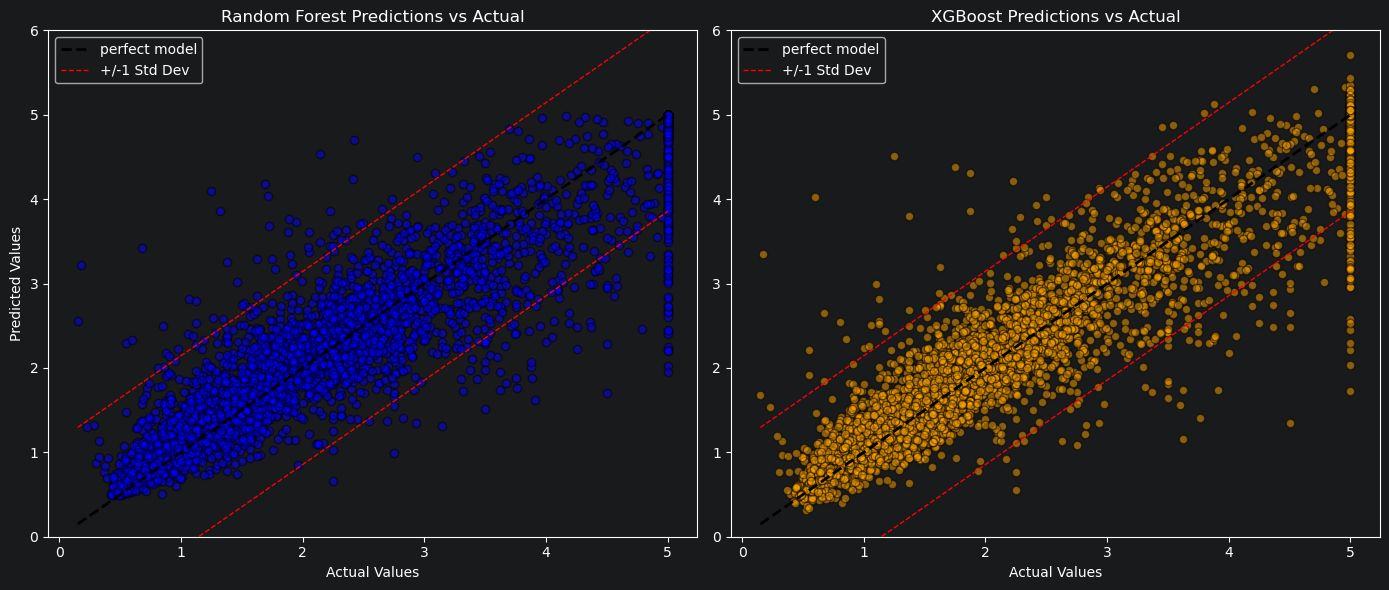

In [17]:
plt.figure(figsize=(14, 6))

# Random Forest
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="blue", ec="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], "r--", lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], "r--", lw=1)
plt.ylim(0,6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

# XGBoost
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color="orange",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], "r--", lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], "r--", lw=1, )
plt.ylim(0,6)
plt.title("XGBoost Predictions vs Actual")
plt.xlabel("Actual Values")
plt.legend()
plt.tight_layout()

<p>Both models performed very well. Most of their predictions fall within a standard deviation of the target. Interestingly, random forest "respects" the upper bound (the maximum value) present in the target by staying within its limits, while XGBoost "overshoots", or exceeds this limit.</p>

****
This is the end of the file.
****